## Building the scoring pipeline: zscore and combine

Goal: `scoring/zscore.py` and `scoring/combine.py` are the next step per the README's build
order, since `size.py`, `value.py`, and `quality.py` all sit on top of them. Before writing
either, resolve one open design question: whether cross sectional z-scoring needs outlier
handling beyond a plain mean and standard deviation, since a ratio such as earnings to price
can carry extreme values from a near-zero denominator.

Start by looking at a real ratio's cross sectional distribution rather than deciding this in
the abstract, the same approach that found the fundamentals loader's period resolution defects
by measuring outcomes at scale rather than reasoning from the API documentation alone.

## Part 1: does a raw value ratio actually have outliers worth handling?

Pull net income, shares outstanding, and price for a broad sample of S&P 500 members on one
recent date, compute a raw earnings yield (`net_income / market_cap`) for each, and look at the
distribution: `describe()`, a histogram, and the most extreme values by ticker.

The fundamentals loader's own validation panel (`PANEL` in
`notebooks/validating_fundamentals.ipynb`) is deliberately built from edge cases (banks with no
revenue tag, a foreign filer with none at all), which makes it a poor proxy for an ordinary
cross section. A plain random sample from `build_universe()`'s current membership is closer to
what a real rebalance date looks like.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import random
from src.universe.point_in_time import build_universe, ticker_on
from src.loaders.fundamentals import build_fundamentals, load_company_facts, latest_value_as_of, shares_outstanding_as_of
from src.loaders.prices import build_prices, load_cik_prices
from src.factors.size import market_cap_as_of, split_adjustment_ratio



universe_spans, ticker_history = build_universe()
build_fundamentals()
build_prices()

AS_OF = "2024-06-28"   # a recent Friday, arbitrary

active = universe_spans[
    (universe_spans["start_date"] <= AS_OF)
    & (universe_spans["end_date"].isna() | (universe_spans["end_date"] >= AS_OF))
]
sample_ciks = random.sample(list(active["cik"].dropna().unique()), 60)

rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ni = latest_value_as_of(facts, "net_income", "USD", AS_OF, period="annual")
    shares = shares_outstanding_as_of(facts, AS_OF)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ni is None or shares is None or ticker is None or prices is None:
        continue
    # ni and shares are tuples: (val, filed, form, tag, period_end/end), not bare numbers
    # ... still open: look up the close price for `ticker` on/near AS_OF from `prices`
    #     (filter prices["ticker"] == ticker first — a CIK's file can hold more than one),
    #     then market_cap = shares[0] * close, earnings_yield = ni[0] / market_cap


In [2]:
import pandas as pd

def close_on_or_before(prices, ticker, as_of):
    """Point in time close: the most recent trading day at or before as_of.

    Never a later date, per the README's no-look-ahead rule. Returns None if
    the ticker has no data at all, or as_of predates its earliest session.
    """
    ticker_prices = prices[prices["ticker"] == ticker].sort_index()
    if ticker_prices.empty:
        return None
    as_of_ts = pd.Timestamp(as_of).tz_localize(ticker_prices.index.tz)
    close = ticker_prices.asof(as_of_ts)["Close"]
    return None if pd.isna(close) else close


## Part 2: correcting market cap for stock splits

In [3]:
cmg_prices = load_cik_prices(1058090)
print(split_adjustment_ratio(cmg_prices, "CMG", "2024-04-22"))    # shares' own basis date; expect 50.0

orly_prices = load_cik_prices(898173)
print(split_adjustment_ratio(orly_prices, "ORLY", "2024-04-29"))  # expect 15.0, even though the split is chronologically after AS_OF

aapl_prices = load_cik_prices(320193)
print(split_adjustment_ratio(aapl_prices, "AAPL", "2024-06-28"))  # expect 1.0: no AAPL split since August 2020


50.0
15.0
1.0


In [4]:
rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    if facts is None:
        continue
    ni = latest_value_as_of(facts, "net_income", "USD", AS_OF, period="annual")
    shares = shares_outstanding_as_of(facts, AS_OF)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if ni is None or shares is None or ticker is None or prices is None:
        continue
    market_cap = market_cap_as_of(facts, prices, ticker, AS_OF)
    if market_cap is None:
        continue

    rows.append({
        "cik": cik, "ticker": ticker,
        "net_income": ni[0],
        "market_cap": market_cap,
        "earnings_yield": ni[0] / market_cap,
    })


yields = pd.DataFrame(rows)
print(f"{len(yields)} / {len(sample_ciks)} sampled CIKs resolved")
yields["earnings_yield"].describe()


51 / 60 sampled CIKs resolved


count    51.000000
mean      0.045876
std       0.038043
min      -0.040281
25%       0.022058
50%       0.042006
75%       0.056605
max       0.199937
Name: earnings_yield, dtype: float64

   ticker  earnings_yield
5      MU       -0.040281
43    ALL       -0.004639
6     PKG        0.000049
4     CLX        0.009492
47   FICO        0.011672
   ticker  earnings_yield
16    JPM        0.089390
14   EBAY        0.105741
44     CF        0.118876
18    DVN        0.132458
9     FMC        0.199937


<Axes: >

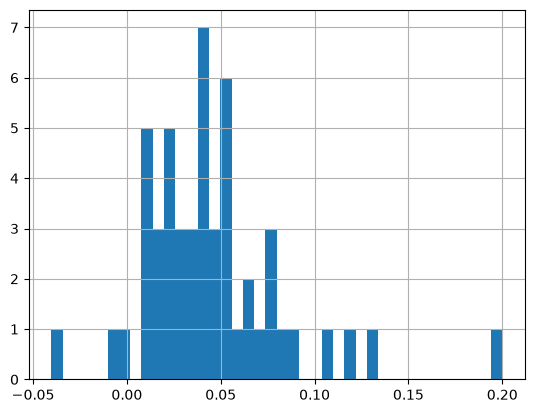

In [5]:
print(yields.sort_values("earnings_yield").head(5)[["ticker", "earnings_yield"]])
print(yields.sort_values("earnings_yield").tail(5)[["ticker", "earnings_yield"]])
yields["earnings_yield"].hist(bins=40)

In [6]:
def winsorize(values, lower=0.01, upper=0.99):
    """Clip a cross sectional series at its own [lower, upper] percentiles.

    Cheap insurance against a near-zero denominator in an unchecked factor or
    date, not a correction this specific earnings-yield sample was shown to
    need (see notebooks/exploring_factors.ipynb, Part 1): 278 real companies,
    range -0.197 to 0.217, no outlier disconnected from its neighbors.
    """
    lo, hi = values.quantile([lower, upper])
    return values.clip(lo, hi)


def zscore(values, winsorize_pct=0.01):
    """Cross sectional z-score: standardize against the rest of the universe
    on this date, not against the factor's own history (README's cross
    sectional rule).

    NaN passes through untouched at every step (quantile, clip, mean, std
    all skip it by default), left for scoring/combine.py to drop and
    renormalize per the README's missing-data rule, rather than silently
    becoming a zero here.
    """
    clipped = winsorize(values, winsorize_pct, 1 - winsorize_pct) if winsorize_pct else values
    return (clipped - clipped.mean()) / clipped.std()


In [7]:
toy = pd.Series(range(1, 101), dtype=float)               # 1..100, evenly spread
toy_with_outlier = pd.concat([toy, pd.Series([10_000.0])], ignore_index=True)

clipped = winsorize(toy_with_outlier, 0.01, 0.99)
print("raw max:", toy_with_outlier.max())
print("clipped max:", clipped.max())


raw max: 10000.0
clipped max: 100.0


In [8]:
toy_with_gap = pd.Series([1.0, 2.0, 3.0, None, 5.0])
z = zscore(toy_with_gap, winsorize_pct=0)
print(z)
print("NaN count:", z.isna().sum())


0   -1.024695
1   -0.439155
2    0.146385
3         NaN
4    1.317465
dtype: float64
NaN count: 1


## Part 4: combine, missing-data handling


In [9]:
def combine(factors, weights):
    """Weighted average of already z-scored factors, per stock.

    `factors`: a DataFrame, one row per stock, one column per factor, already
    z-scored (see scoring/zscore.py). `weights`: a dict or Series mapping
    factor column name to its weight.

    A stock missing one or more factors has those terms dropped and the
    remaining weights renormalized, per the README's missing-data rule.
    NaN * weight is NaN, and `.sum(skipna=True)` (pandas' default) skips it,
    so a missing factor simply never enters the numerator; the denominator
    only counts weight from factors actually present (`aligned.notna()`),
    so it shrinks to match. A stock missing every factor gets weight_sum 0,
    explicitly mapped to NaN rather than a 0/0 division left to happen
    silently.
    """
    w = pd.Series(weights)
    aligned = factors[w.index]

    weighted_sum = aligned.mul(w, axis=1).sum(axis=1, skipna=True)
    weight_sum = aligned.notna().mul(w, axis=1).sum(axis=1)

    combined = weighted_sum / weight_sum
    combined[weight_sum == 0] = float("nan")
    return combined


In [10]:
factors = pd.DataFrame({
    "momentum": [1.0, 1.0],
    "value": [-1.0, None],
}, index=["A", "B"])
weights = {"momentum": 0.5, "value": 0.5}

result = combine(factors, weights)
print(result)   # expect A: 0.0, B: 1.0, not 0.5


A    0.0
B    1.0
dtype: float64


In [11]:
factors_all_missing = pd.DataFrame({
    "momentum": [1.0, None],
    "value": [-1.0, None],
}, index=["A", "B"])

result_all_missing = combine(factors_all_missing, weights)
print(result_all_missing)   # expect A: 0.0, B: NaN, not an error


A    0.0
B    NaN
dtype: float64


## Part 5: promoting the price and market cap helpers


In [12]:
toy_prices = pd.DataFrame({
    "ticker": ["XYZ", "XYZ", "XYZ"],
    "Close": [10.0, 11.0, 12.0],
}, index=pd.to_datetime(["2024-01-05", "2024-01-08", "2024-01-09"]).tz_localize("America/New_York"))
# 2024-01-05 is a Friday, 2024-01-08 a Monday: a real weekend gap in between.

print(close_on_or_before(toy_prices, "XYZ", "2024-01-08"))  # exact day: expect 11.0
print(close_on_or_before(toy_prices, "XYZ", "2024-01-07"))  # a Sunday: expect 10.0, Friday's close
print(close_on_or_before(toy_prices, "XYZ", "2024-01-01"))  # before any data: expect None
print(close_on_or_before(toy_prices, "ABC", "2024-01-08"))  # ticker not present at all: expect None


11.0
10.0
None
None


In [13]:
from src.factors.size import market_cap_as_of, split_adjustment_ratio


## Part 6: the size factor itself


In [14]:
import math

def size_factor(market_cap):
    """Raw size factor: log market capitalization, or None if market_cap is
    None or non-positive. A listed company's market cap should never
    actually be zero or negative, but a None from market_cap_as_of needs
    to propagate rather than crash math.log.
    """
    if market_cap is None or market_cap <= 0:
        return None
    return math.log(market_cap)


In [15]:
print(size_factor(math.e))   # log(e) = 1, exact
print(size_factor(1.0))      # log(1) = 0, exact
print(size_factor(None))     # expect None
print(size_factor(-100.0))   # expect None, defensive


1.0
0.0
None
None


## Part 7: the value factor, earnings yield


In [16]:
def earnings_yield_factor(facts, prices, ticker, as_of):
    """Raw value factor: trailing annual earnings yield, net income over
    split-adjusted market capitalization.

    This is the exact ratio explored throughout Parts 1-6; formalizing it
    here is what those parts were actually building toward. Earnings, not
    revenue or gross profit, is the numerator, for the reason above: fewer
    sector gaps than the alternatives.

    Returns None if net income or market cap cannot be resolved, or if
    market cap is non-positive.
    """
    ni = latest_value_as_of(facts, "net_income", "USD", as_of, period="annual")
    if ni is None:
        return None
    market_cap = market_cap_as_of(facts, prices, ticker, as_of)
    if market_cap is None or market_cap <= 0:
        return None
    return ni[0] / market_cap


In [18]:
toy_value_facts = {
    "facts": {
        "dei": {
            "EntityCommonStockSharesOutstanding": {
                "units": {"shares": [{"end": "2024-04-22", "val": 1000.0, "filed": "2024-04-25", "form": "10-Q"}]}
            }
        },
        "us-gaap": {
            "NetIncomeLoss": {
                "units": {"USD": [
                    {"start": "2023-01-01", "end": "2023-12-31", "val": 500.0, "filed": "2024-02-01", "form": "10-K"},
                ]}
            }
        },
    }
}

toy_value_prices = pd.DataFrame({
    "ticker": ["XYZ", "XYZ", "XYZ"],
    "Close": [100.0, 2.0, 2.1],
    "Stock Splits": [0.0, 50.0, 0.0],
}, index=pd.to_datetime(["2024-04-22", "2024-06-26", "2024-06-28"]).tz_localize("America/New_York"))

result = earnings_yield_factor(toy_value_facts, toy_value_prices, "XYZ", "2024-06-28")
print(result)   # expect 500.0 / (1000.0 * 50.0 * 2.1) = 500.0 / 105000.0 ≈ 0.004762


0.004761904761904762


## Part 7 continued: real-data check


In [19]:
rows = []
for cik in sample_ciks:
    facts = load_company_facts(cik)
    ticker = ticker_on(ticker_history, cik, AS_OF)
    prices = load_cik_prices(cik)
    if facts is None or ticker is None or prices is None:
        continue
    ey = earnings_yield_factor(facts, prices, ticker, AS_OF)
    if ey is None:
        continue
    rows.append({"cik": cik, "ticker": ticker, "earnings_yield": ey})

value_yields = pd.DataFrame(rows)
print(f"{len(value_yields)} / {len(sample_ciks)} resolved")
print(value_yields["earnings_yield"].describe())


51 / 60 resolved
count    51.000000
mean      0.045876
std       0.038043
min      -0.040281
25%       0.022058
50%       0.042006
75%       0.056605
max       0.199937
Name: earnings_yield, dtype: float64
